In [ ]:
# Installing Pandas
pip install pandas

In [ ]:
# Installing Matplot Lib
pip install matplotlib

In [ ]:
# Installing Seaborn
pip install seaborn

In [ ]:
# Installing Scipy
pip install scipy

In [1]:
# Importing essential Libbraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats  import zscore

In [2]:
# Imprting the filing & loading it to a pandas Data Frame
path = r"C:\Users\henokt\OneDrive - Inchcape\Documents\KIAM8\Data\data\data\togo-dapaong_qc.csv"
df=pd.read_csv(path.replace('\\','/'))

In [3]:
# Exploring the Data Set
df.describe()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,230.555040,151.258469,116.444352,226.144375,219.568588,27.751788,55.013160,2.368093,3.229490,0.557740,161.741845,10.559568,975.915242,0.000535,0.001382,32.444403,33.543330,NaN
std,322.532347,250.956962,156.520714,317.346938,307.932510,4.758023,28.778732,1.462668,1.882565,0.268923,91.877217,5.915490,2.153977,0.023116,0.026350,10.998334,12.769277,NaN
min,-12.700000,0.000000,0.000000,0.000000,0.000000,14.900000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,968.000000,0.000000,0.000000,13.100000,13.100000,NaN
25%,-2.200000,0.000000,0.000000,0.000000,0.000000,24.200000,26.500000,1.400000,1.900000,0.400000,74.800000,6.900000,975.000000,0.000000,0.000000,23.900000,23.600000,NaN
50%,2.100000,0.000000,2.500000,4.400000,4.300000,27.200000,59.300000,2.200000,2.900000,0.500000,199.100000,10.800000,976.000000,0.000000,0.000000,28.400000,28.400000,NaN
75%,442.400000,246.400000,215.700000,422.525000,411.000000,31.100000,80.800000,3.200000,4.400000,0.700000,233.500000,14.100000,977.000000,0.000000,0.000000,40.600000,43.000000,NaN
max,1424.000000,1004.500000,805.700000,1380.000000,1367.000000,41.400000,99.800000,16.100000,23.100000,4.700000,360.000000,86.900000,983.000000,1.000000,2.300000,70.400000,94.600000,NaN


In [4]:
# Checking for Missing Values-1
df.isna().any()

Timestamp        False
GHI              False
DNI              False
DHI              False
ModA             False
ModB             False
Tamb             False
RH               False
WS               False
WSgust           False
WSstdev          False
WD               False
WDstdev          False
BP               False
Cleaning         False
Precipitation    False
TModA            False
TModB            False
Comments          True
dtype: bool

In [5]:
# Checking for Missing Values-2
df.isna().sum()

Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64

In [6]:
# Checking for Outliers DNI

Q1_GHI = df['GHI'].quantile(0.25)
Q3_GHI = df['GHI'].quantile(0.75)

IQR_GHI = Q3_GHI -Q1_GHI

Lower_Bound_GHI = Q1_GHI - 1.5 * IQR_GHI
Upper_Bound_GHI = Q3_GHI + 1.5 * IQR_GHI

GHI_Outliers = df[(df['GHI']<Lower_Bound_GHI) | (df['GHI']> Upper_Bound_GHI) ]

GHI_Outliers


,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
4985,2021-10-28 11:06,1139.0,805.1,466.1,1172.0,1154.0,29.8,70.8,2.2,2.6,0.4,298.6,13.4,977,0,0.0,44.7,50.2,NaN
4995,2021-10-28 11:16,1112.0,800.3,429.1,1139.0,1120.0,30.5,68.7,3.6,4.4,0.5,283.4,8.1,977,0,0.0,51.3,57.9,NaN
195137,2022-03-09 12:18,1139.0,609.7,543.6,1139.6,1092.0,37.8,4.5,1.0,1.9,0.7,354.4,8.3,973,0,0.0,55.2,59.5,NaN
195138,2022-03-09 12:19,1152.0,619.7,549.9,1155.6,1108.0,37.7,4.4,1.2,1.9,0.6,337.0,18.4,973,0,0.0,57.2,61.1,NaN
195139,2022-03-09 12:20,1155.0,614.7,558.0,1158.6,1112.0,37.7,4.6,1.2,2.1,0.7,312.4,16.3,973,0,0.0,59.4,63.1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510411,2022-10-14 10:52,1162.0,742.9,453.3,1196.2,1179.0,30.1,69.3,4.8,6.2,0.9,167.2,16.1,978,0,0.0,53.2,62.6,NaN
510412,2022-10-14 10:53,1285.0,862.8,460.8,1309.4,1290.0,30.1,67.8,5.1,6.4,0.9,182.7,13.4,978,0,0.0,53.7,62.9,NaN
510413,2022-10-14 10:54,1202.0,748.9,494.9,1242.3,1225.0,30.1,68.0,4.4,6.4,1.2,169.9,10.9,978,0,0.0,54.2,63.4,NaN
510414,2022-10-14 10:55,1267.0,790.9,514.5,1299.4,1280.0,30.1,68.6,4.0,5.2,0.9,160.1,15.0,978,0,0.0,54.9,64.3,NaN


In [7]:
# Checking for Outliers DHI

Q1_DHI = df['DHI'].quantile(0.25)
Q3_DHI = df['DHI'].quantile(0.75)

IQR_DHI = Q3_DHI -Q1_DHI

Lower_Bound_DHI = Q1_DHI - 1.5 * IQR_DHI
Upper_Bound_DHI = Q3_DHI + 1.5 * IQR_DHI

DHI_Outliers = df[(df['DHI']<Lower_Bound_DHI) | (df['DHI']> Upper_Bound_DHI) ]

DHI_Outliers

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
559,2021-10-25 09:20,606.4,106.1,551.5,614.2,607.6,29.4,74.2,2.8,3.4,0.5,216.3,18.2,979,0,0.0,43.2,48.9,NaN
560,2021-10-25 09:21,678.5,187.9,564.2,688.7,681.0,29.4,75.8,2.4,3.1,0.5,217.5,15.2,979,0,0.0,43.6,49.5,NaN
561,2021-10-25 09:22,651.1,142.4,570.9,661.0,653.7,29.5,74.4,2.6,3.1,0.4,225.5,16.3,979,0,0.0,44.0,50.1,NaN
562,2021-10-25 09:23,659.3,142.5,575.4,664.2,656.8,29.5,74.9,2.6,3.6,0.5,225.5,20.7,979,0,0.0,44.5,50.8,NaN
563,2021-10-25 09:24,617.6,86.1,575.8,621.9,615.1,29.5,74.3,3.6,4.4,0.5,237.4,6.4,979,0,0.0,44.9,51.3,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510555,2022-10-14 13:16,579.2,20.2,543.6,569.9,564.7,30.0,69.3,2.3,4.1,0.8,188.3,13.9,976,0,0.0,45.0,47.0,NaN
522047,2022-10-22 12:48,919.0,387.0,539.8,960.3,921.0,34.2,38.8,3.5,4.6,0.7,127.0,11.1,976,0,0.0,50.2,51.9,NaN
522054,2022-10-22 12:55,817.0,273.0,544.5,855.8,820.0,34.1,38.4,1.8,2.6,0.5,111.7,23.0,976,0,0.0,49.7,51.4,NaN
522055,2022-10-22 12:56,924.0,384.4,550.3,968.5,928.0,34.2,37.5,2.5,3.4,0.6,76.3,23.6,976,0,0.0,50.2,51.8,NaN


In [8]:
# Checking for Outliers DHI

Q1_DHI = df['DHI'].quantile(0.25)
Q3_DHI = df['DHI'].quantile(0.75)

IQR_DHI = Q3_DHI -Q1_DHI

Lower_Bound_DHI = Q1_DHI - 1.5 * IQR_DHI
Upper_Bound_DHI = Q3_DHI + 1.5 * IQR_DHI

DHI_Outliers = df[(df['DHI']<Lower_Bound_DHI) | (df['DHI']> Upper_Bound_DHI) ]

DHI_Outliers

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
559,2021-10-25 09:20,606.4,106.1,551.5,614.2,607.6,29.4,74.2,2.8,3.4,0.5,216.3,18.2,979,0,0.0,43.2,48.9,NaN
560,2021-10-25 09:21,678.5,187.9,564.2,688.7,681.0,29.4,75.8,2.4,3.1,0.5,217.5,15.2,979,0,0.0,43.6,49.5,NaN
561,2021-10-25 09:22,651.1,142.4,570.9,661.0,653.7,29.5,74.4,2.6,3.1,0.4,225.5,16.3,979,0,0.0,44.0,50.1,NaN
562,2021-10-25 09:23,659.3,142.5,575.4,664.2,656.8,29.5,74.9,2.6,3.6,0.5,225.5,20.7,979,0,0.0,44.5,50.8,NaN
563,2021-10-25 09:24,617.6,86.1,575.8,621.9,615.1,29.5,74.3,3.6,4.4,0.5,237.4,6.4,979,0,0.0,44.9,51.3,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510555,2022-10-14 13:16,579.2,20.2,543.6,569.9,564.7,30.0,69.3,2.3,4.1,0.8,188.3,13.9,976,0,0.0,45.0,47.0,NaN
522047,2022-10-22 12:48,919.0,387.0,539.8,960.3,921.0,34.2,38.8,3.5,4.6,0.7,127.0,11.1,976,0,0.0,50.2,51.9,NaN
522054,2022-10-22 12:55,817.0,273.0,544.5,855.8,820.0,34.1,38.4,1.8,2.6,0.5,111.7,23.0,976,0,0.0,49.7,51.4,NaN
522055,2022-10-22 12:56,924.0,384.4,550.3,968.5,928.0,34.2,37.5,2.5,3.4,0.6,76.3,23.6,976,0,0.0,50.2,51.8,NaN


In [9]:
##df_zscore_scipy = df['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust'].select_dtypes(include=np.number).apply(zscore)
df_zscore_scipy = df[['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']].apply(zscore)
df_zscore_scipy = df_zscore_scipy>3
df_zscore_scipy.sum()

GHI        305
DNI       1062
DHI       3415
ModA       137
ModB       206
WS        3510
WSgust    3915
dtype: int64

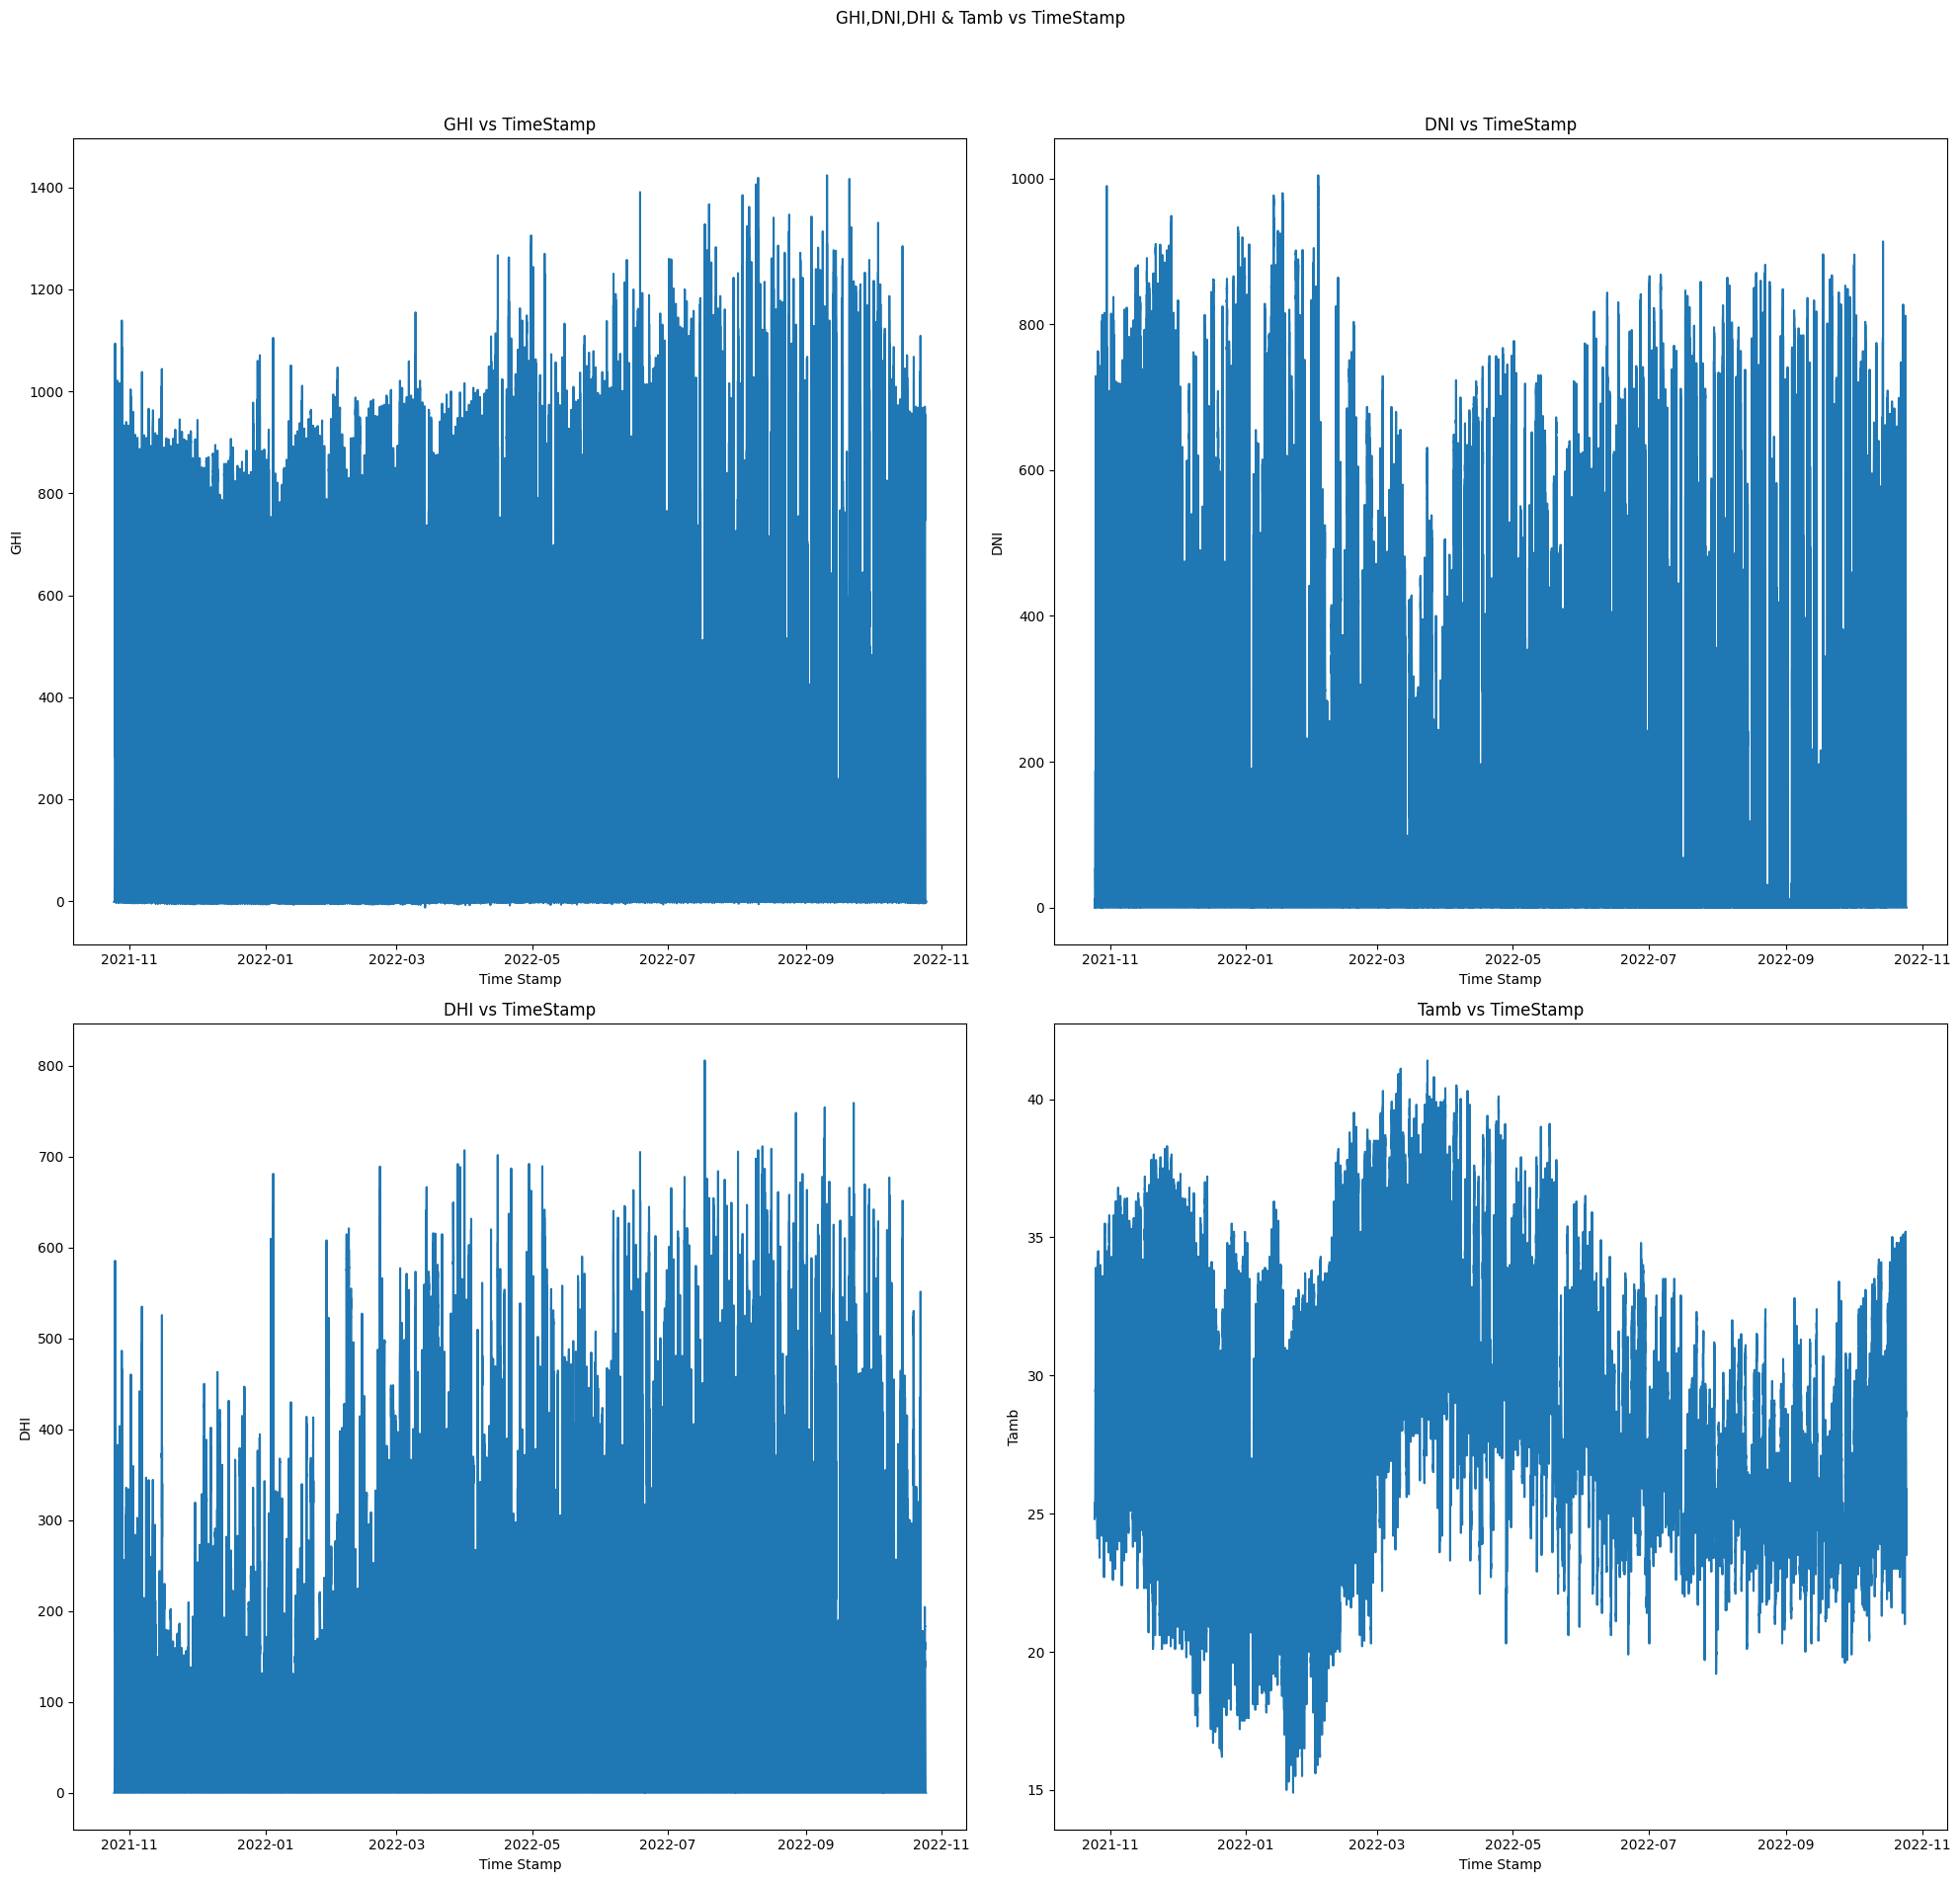

In [10]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

fig,axes = plt.subplots(nrows=2,ncols=2,figsize=(20,20))

axes[0,0].plot(df['Timestamp'], df['GHI'])
axes[0,0].set_xlabel('Time Stamp')
axes[0,0].set_ylabel('GHI')
axes[0,0].set_title('GHI vs TimeStamp')

axes[0,1].plot(df['Timestamp'], df['DNI'])
axes[0,1].set_xlabel('Time Stamp')
axes[0,1].set_ylabel('DNI')
axes[0,1].set_title('DNI vs TimeStamp')

axes[1,0].plot(df['Timestamp'], df['DHI'])
axes[1,0].set_xlabel('Time Stamp')
axes[1,0].set_ylabel('DHI')
axes[1,0].set_title('DHI vs TimeStamp')

axes[1,1].plot(df['Timestamp'], df['Tamb'])
axes[1,1].set_xlabel('Time Stamp')
axes[1,1].set_ylabel('Tamb')
axes[1,1].set_title('Tamb vs TimeStamp')

fig.suptitle ('GHI,DNI,DHI & Tamb vs TimeStamp ')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


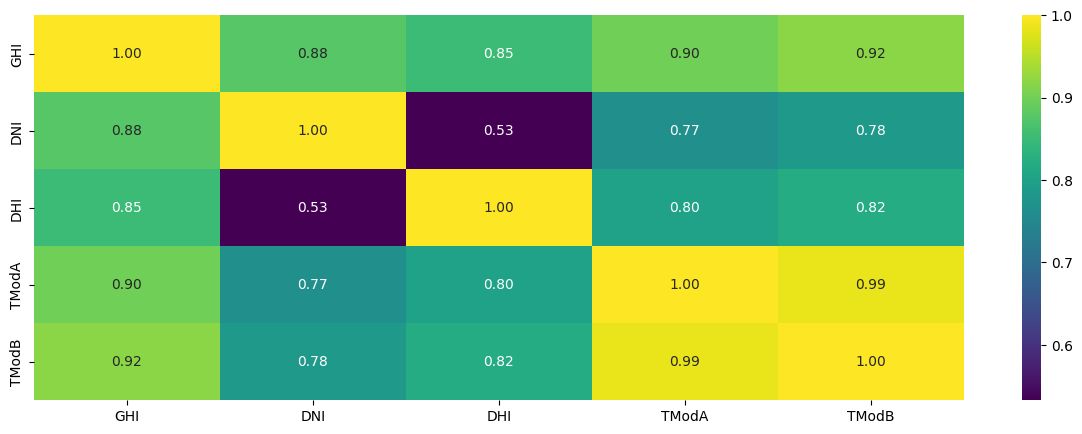

In [11]:
corr = df[['GHI', 'DNI', 'DHI', 'TModA', 'TModB']].corr()
plt.figure(figsize=(15,5))
sns.heatmap(corr,annot=True,fmt ='.2f',cmap='viridis')
plt.show()

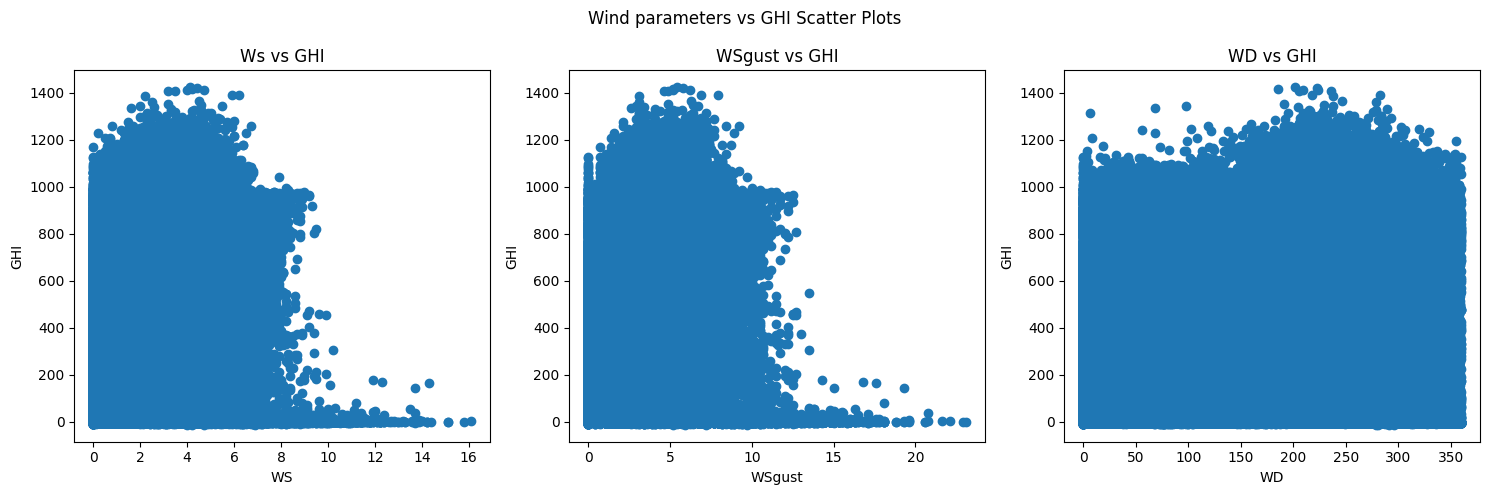

In [12]:
fig,axes =plt.subplots(nrows=1,ncols=3,figsize=(15,5))

axes[0].scatter(df['WS'],df['GHI'])
axes[0].set_xlabel('WS')
axes[0].set_ylabel('GHI')
axes[0].set_title('Ws vs GHI')

axes[1].scatter(df['WSgust'],df['GHI'])
axes[1].set_xlabel('WSgust')
axes[1].set_ylabel('GHI')
axes[1].set_title('WSgust vs GHI')

axes[2].scatter(df['WD'],df['GHI'])
axes[2].set_xlabel('WD')
axes[2].set_ylabel('GHI')
axes[2].set_title('WD vs GHI')

fig.suptitle('Wind parameters vs GHI Scatter Plots')
plt.tight_layout()
plt.show()

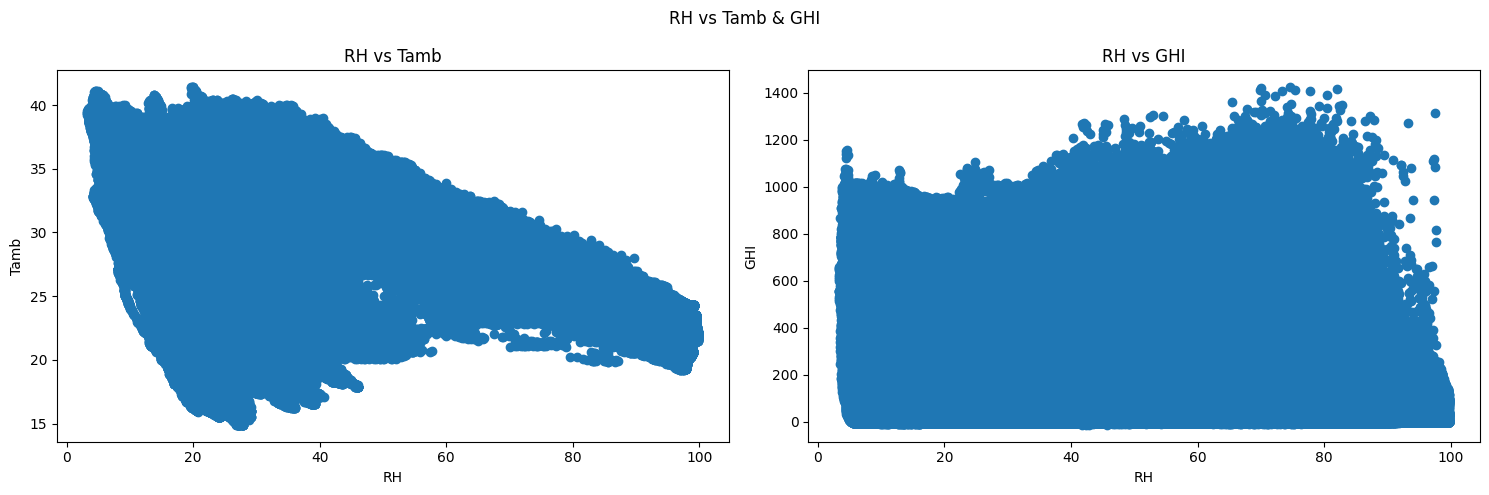

In [13]:
fig,axes = plt.subplots(nrows=1,ncols=2,figsize=(15,5))

axes[0].scatter(df['RH'],df['Tamb'])
axes[0].set_xlabel('RH')
axes[0].set_ylabel('Tamb')
axes[0].set_title ('RH vs Tamb')

axes[1].scatter(df['RH'],df['GHI'])
axes[1].set_xlabel('RH')
axes[1].set_ylabel('GHI')
axes[1].set_title ('RH vs GHI')

plt.suptitle('RH vs Tamb & GHI')
plt.tight_layout()
plt.show()

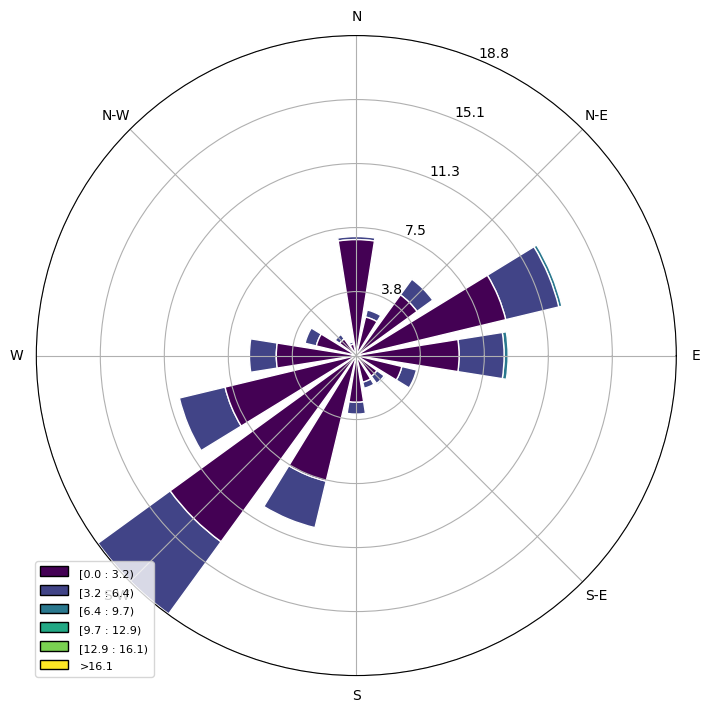

In [14]:
from windrose import WindroseAxes

fig = plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax(fig=fig)
ax.bar(df['WD'],df['WS'], normed=True, opening=0.8, edgecolor='white')
ax.set_legend()
plt.show()

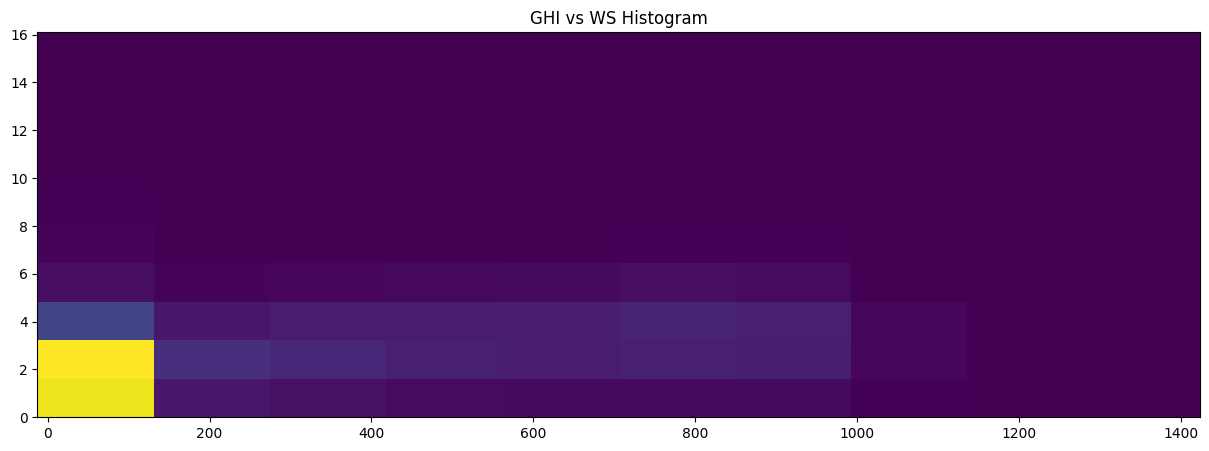

In [15]:
plt.figure(figsize=(15,5))
plt.hist2d(df['GHI'],df['WS'])
plt.title('GHI vs WS Histogram')
plt.show()

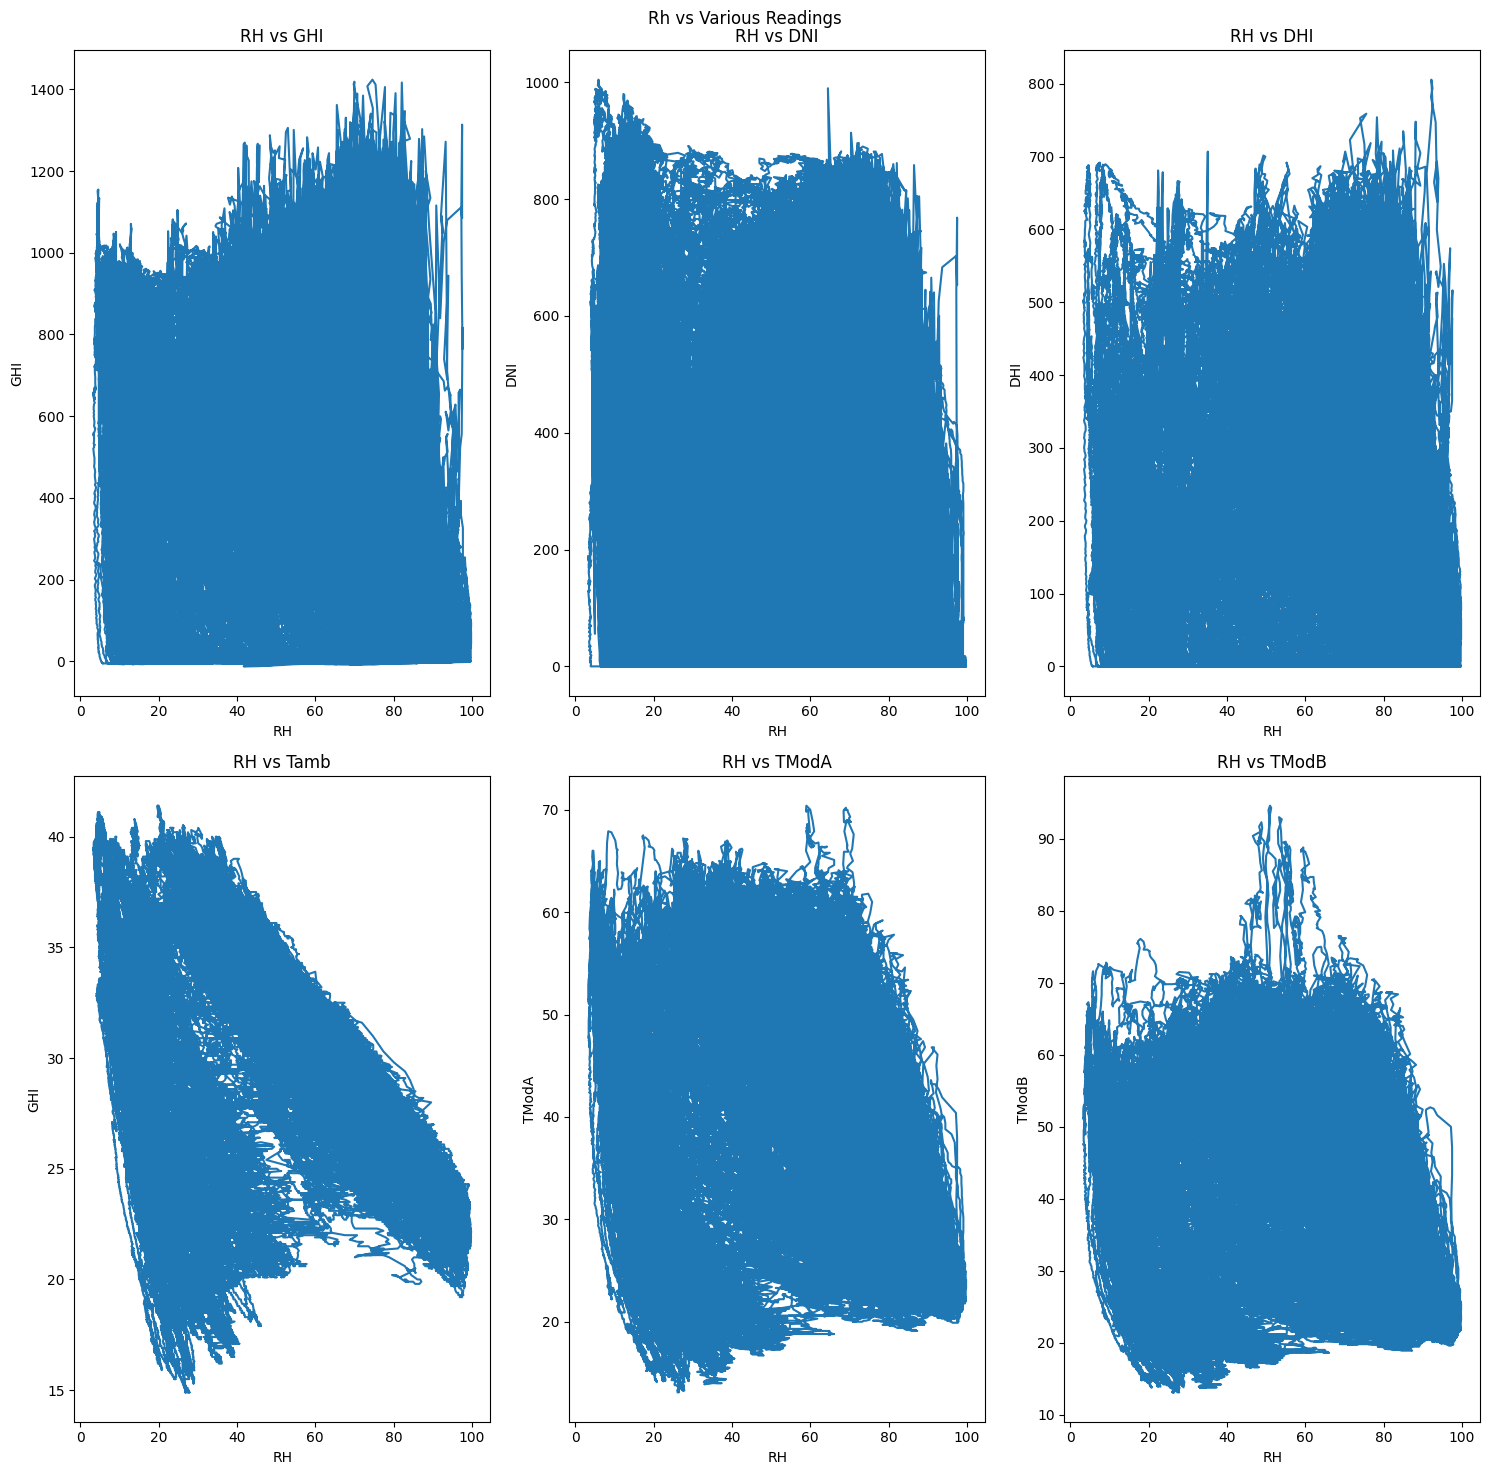

In [16]:
fix,axes =plt.subplots(nrows=2,ncols=3,figsize=(15,15))

axes[0,0].plot(df['RH'],df['GHI'])
axes[0,0].set_xlabel('RH')
axes[0,0].set_ylabel('GHI')
axes[0,0].set_title('RH vs GHI')

axes[0,1].plot(df['RH'],df['DNI'])
axes[0,1].set_xlabel('RH')
axes[0,1].set_ylabel('DNI')
axes[0,1].set_title('RH vs DNI')

axes[0,2].plot(df['RH'],df['DHI'])
axes[0,2].set_xlabel('RH')
axes[0,2].set_ylabel('DHI')
axes[0,2].set_title('RH vs DHI')

axes[1,0].plot(df['RH'],df['Tamb'])
axes[1,0].set_xlabel('RH')
axes[1,0].set_ylabel('GHI')
axes[1,0].set_title('RH vs Tamb')

axes[1,1].plot(df['RH'],df['TModA'])
axes[1,1].set_xlabel('RH')
axes[1,1].set_ylabel('TModA')
axes[1,1].set_title('RH vs TModA')

axes[1,2].plot(df['RH'],df['TModB'])
axes[1,2].set_xlabel('RH')
axes[1,2].set_ylabel('TModB')
axes[1,2].set_title('RH vs TModB')


plt.suptitle('Rh vs Various Readings')
plt.tight_layout()
plt.show()

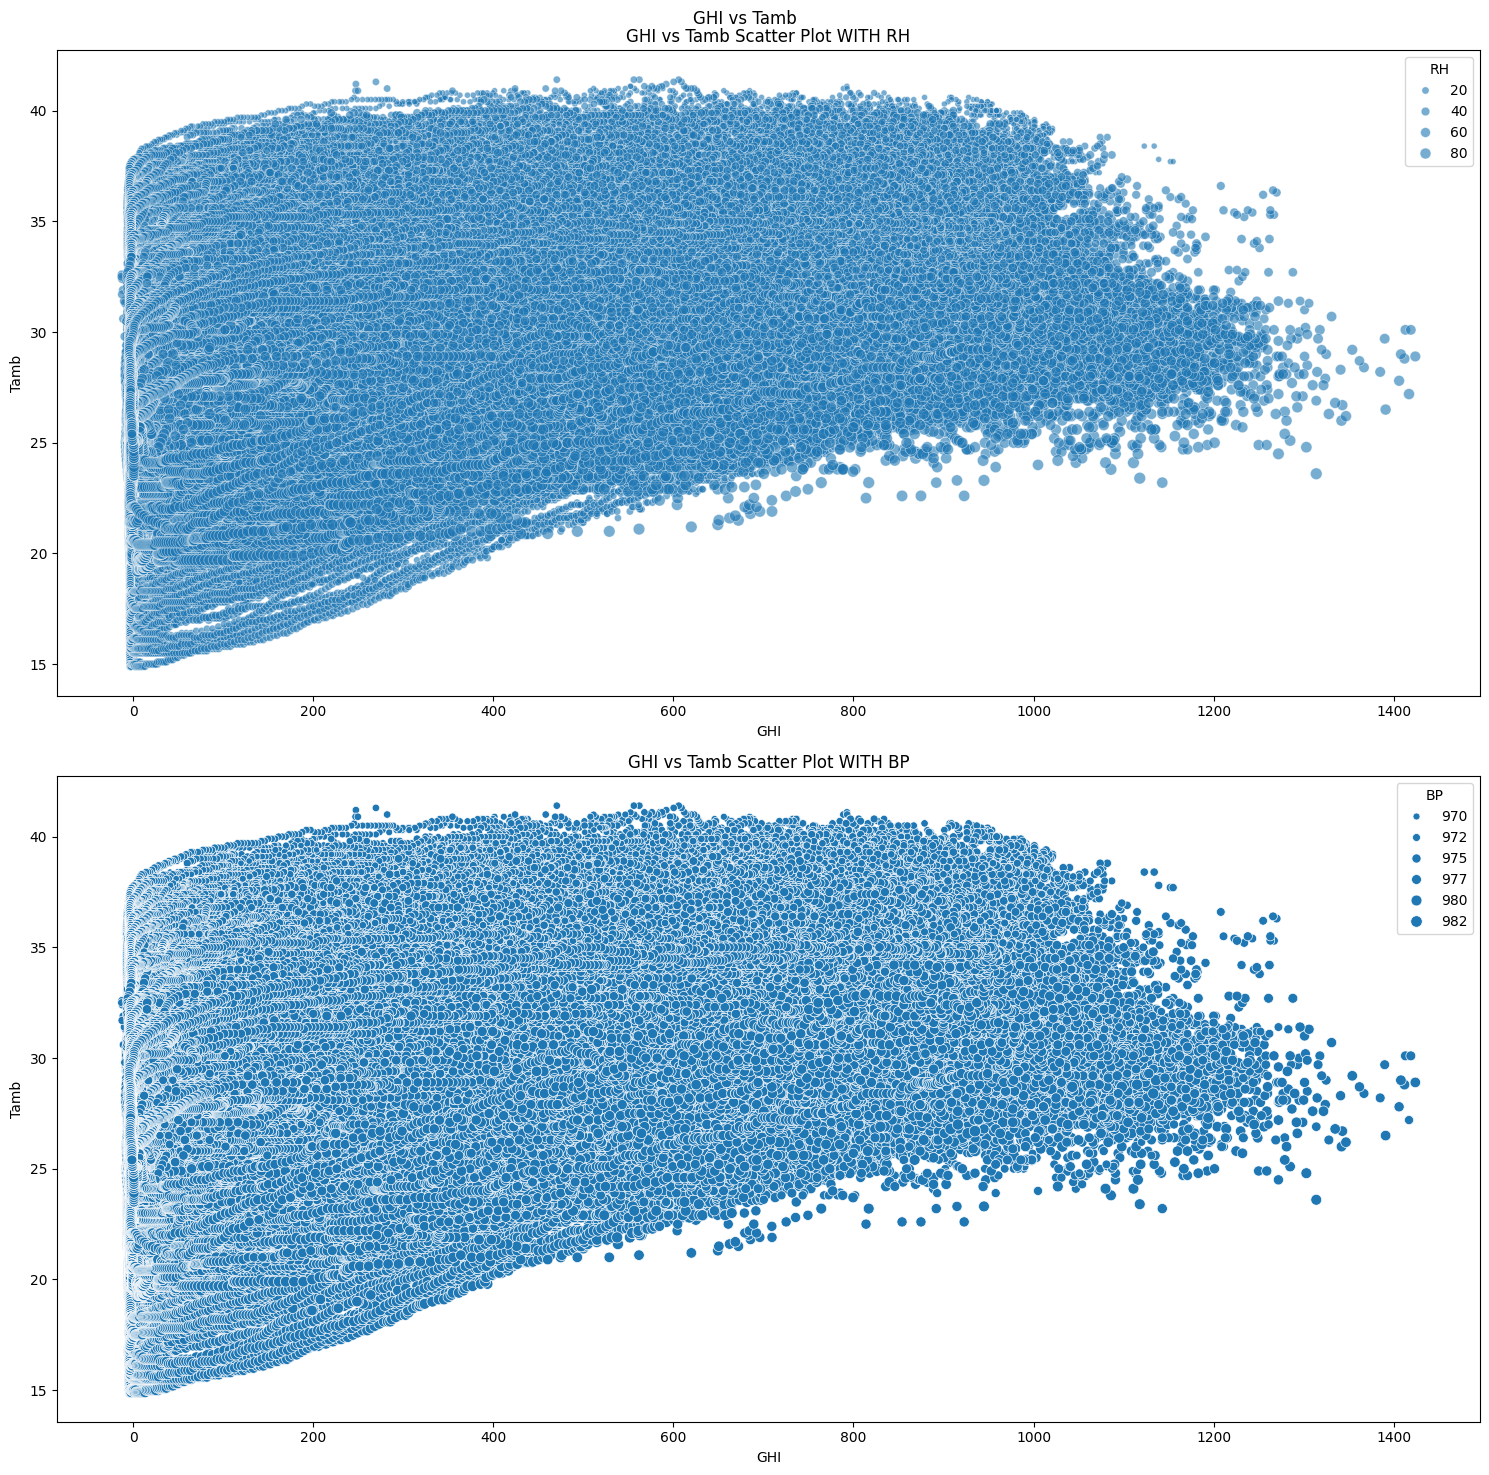

In [17]:
fig,axes=plt.subplots(nrows=2,ncols=1,figsize=(15,15))

sns.scatterplot(x='GHI',y='Tamb',data=df,size='RH',ax=axes[0],alpha=0.6)
axes[0].set_xlabel('GHI')
axes[0].set_ylabel('Tamb')
axes[0].set_title('GHI vs Tamb Scatter Plot WITH RH')

sns.scatterplot(x='GHI',y='Tamb',data=df,size='BP',ax=axes[1])
axes[1].set_xlabel('GHI')
axes[1].set_ylabel('Tamb')
axes[1].set_title('GHI vs Tamb Scatter Plot WITH BP')

plt.suptitle('GHI vs Tamb')

plt.tight_layout()
plt.show()